# Customer Segmentation

### Questions that the clustering dataset should answer: 

- Who spends a lot?
- Who uses promotions?
- Who has families?
- Who is loyal?
- Who buys electronics?
- Who buys groceries?

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
customer_info = pd.read_csv("customer_info_clean.csv")

In [12]:
customer_info.shape

(33038, 26)

In [13]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  float64
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   age                                      33038 non-null  float64
 4   kids_home                                33038 non-null  float64
 5   teens_home                               33038 non-null  float64
 6   number_complaints                        33038 non-null  float64
 7   distinct_stores_visited                  33038 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               33038 non-null  float64
 10  typical_hour                             33038

### Remove columns that should NOT be used for clustering

In [14]:
drop_cols = [
    'customer_id',      # identifier
    'customer_name',    # identifier
    'age_group'         # duplicate of age
]

customer_seg = customer_info.drop(columns=drop_cols)

## Encode Gender

In [ ]:
# Since K-Meand can't use text, I encoded the genders. 
customer_seg['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

In [16]:
customer_seg['customer_gender'] = customer_seg['customer_gender'].map({
    'female': 0,
    'male': 1
})

In [17]:
customer_seg['customer_gender'].value_counts()

customer_gender
0    16577
1    16461
Name: count, dtype: int64

In [18]:
# Checking to make sure no all culumns are numeric.
customer_seg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_gender                          33038 non-null  int64  
 1   age                                      33038 non-null  float64
 2   kids_home                                33038 non-null  float64
 3   teens_home                               33038 non-null  float64
 4   number_complaints                        33038 non-null  float64
 5   distinct_stores_visited                  33038 non-null  float64
 6   lifetime_spend_groceries                 33038 non-null  float64
 7   lifetime_spend_electronics               33038 non-null  float64
 8   typical_hour                             33038 non-null  float64
 9   lifetime_spend_vegetables                33038 non-null  float64
 10  lifetime_spend_nonalcohol_drinks         33038

## Feature Selection

In [ ]:
# I decided to drop latitude and longitude because the goal of the
# clustering analysis is to identify customer purchasing behaviours
# rather than geographical patterns.

# I also removed has_loyalty_card from the clustering variables.
# Since one of the objectives is to identify loyal customers, including
# this variable could cause the clusters to be driven by existing loyalty
# card membership rather than underlying customer behaviour.

# The variable will be retained separately and used later for cluster
# profiling and interpretation.
customer_seg = customer_seg.drop(
    columns=[
        'latitude',
        'longitude',
        'has_loyalty_card'
    ]
)

In [20]:
customer_seg.shape

(33038, 20)

## Standardization

Since K-Means is distance-based, all variables were standardized to ensure that variables with larger magnitudes do not dominate the clustering process.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(customer_seg)

customer_scaled = pd.DataFrame(
    customer_scaled,
    columns=customer_seg.columns
)

customer_scaled.head()

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
0,-0.996495,0.080407,0.016394,0.238641,0.146181,-0.096685,-0.393967,0.890367,-0.134436,-0.539432,-0.516478,-0.886736,-1.475436,-0.810334,-0.444257,-0.112396,0.319240,0.393485,1.125736,0.933618
1,-0.996495,-0.252436,0.016394,-1.127304,-1.175164,-0.704196,-0.196193,-0.609684,-0.134436,2.009069,0.258723,-1.053435,-1.443501,-1.221291,1.838389,0.253501,2.138811,-0.175329,-0.601680,-0.461969
2,1.003517,-0.030541,-1.271628,-1.127304,0.146181,-0.704196,-0.325860,-1.012066,-0.342479,-0.256438,-1.335976,-1.006678,1.158074,-0.685802,-0.521606,-0.848941,-0.729766,-0.647734,-0.891304,-2.056926
3,1.003517,-0.640753,-1.271628,-1.127304,1.467525,-1.311706,-0.820951,-0.550351,1.113819,-0.988802,1.085605,1.056741,0.534292,0.995384,-0.559421,2.168518,-0.975829,-0.541684,-0.229741,1.132987
4,1.003517,0.080407,-1.271628,-1.127304,2.128197,-1.311706,-0.650278,2.454767,0.905776,-0.528547,0.476518,0.213077,0.738671,0.854247,-0.882567,2.168518,0.688334,-1.370803,-0.470150,1.132987


## Elbow Method

### Determining the Optimal Number of Clusters

The Elbow Method was used to identify a suitable number of clusters by examining the reduction in within-cluster variation (inertia).

In [23]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(customer_scaled)

    inertia.append(kmeans.inertia_)

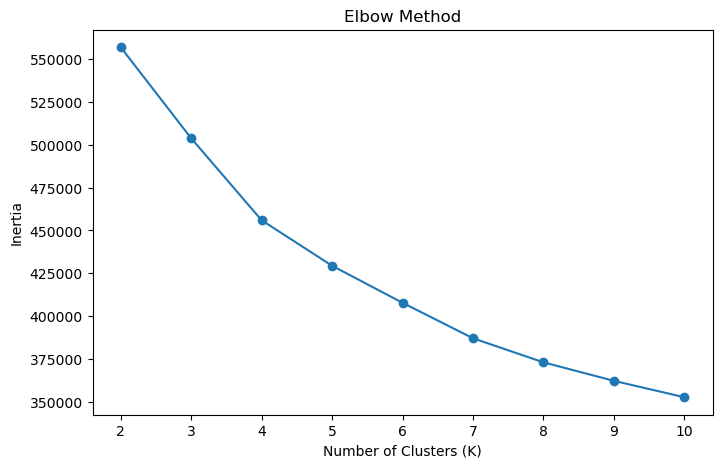

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Based on the elbow plot. It would seem that the optimal number of clusters lies around K = 4 because  the reduction in inertia begins to diminish beyond this point. But it alone can't be the deciding factor. 

## Silhouette Analysis

In [25]:
sil_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(customer_scaled)

    score = silhouette_score(
        customer_scaled,
        labels
    )

    sil_scores.append(score)

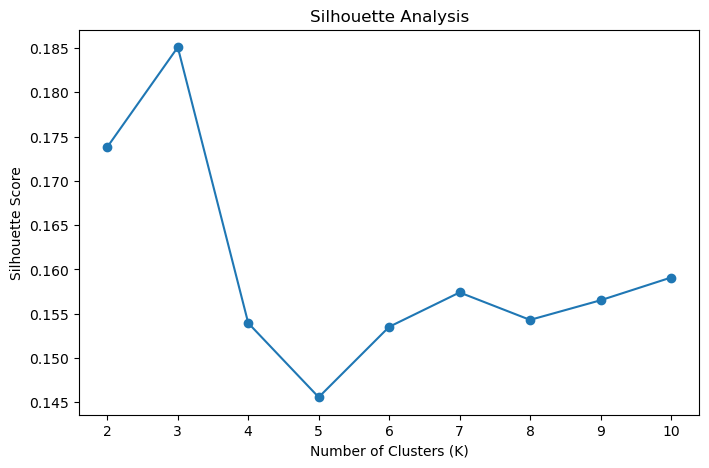

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

The highest sihoutte score is K = 3

### Selecting the Number of Clusters

The Elbow Method suggested that the optimal number of clusters lies between 3 and 4. However, the Silhouette Analysis produced the highest score at K = 3, indicating better cluster separation and cohesion.

Therefore, K = 3 was selected as the final number of clusters.

In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_seg['cluster'] = kmeans.fit_predict(customer_scaled)

In [28]:
customer_seg['cluster'].value_counts()

cluster
0    21166
1     7809
2     4063
Name: count, dtype: int64

In [29]:
cluster_profile = customer_seg.groupby('cluster').mean()

cluster_profile

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
cluster,,,,,,,,,,,,,,,,,,,,
0,0.498252,53.828688,0.943967,0.723306,0.845460,3.300293,12844.147595,1136.782718,11.909383,882.322185,350.658722,359.279859,516.874327,377.555962,824.051309,181.641501,333.063569,112.671572,0.325883,2015.679321
1,0.510309,57.890383,1.500384,1.383468,1.006019,3.595211,26478.150852,3960.675247,11.991548,555.132699,743.695928,1045.843066,1216.329748,1108.231976,1046.593290,349.913305,361.242541,269.209886,0.311993,2012.852798
2,0.475018,51.891952,0.226680,0.283780,0.893921,1.585774,9384.760276,6161.010829,17.742801,190.620262,508.033227,1104.347157,832.653458,809.820207,285.817130,655.199114,292.203913,100.590943,0.285835,2018.166872
